In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Compute HDR metrics (Reinhard tonemap) — parallel, editable
Edit the config below and run cells. Similar to `test_hdr_metrics_sai.ipynb`.

In [11]:
# CONDA ENVIRONMENT P312
import os
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import csv
import gc
from pathlib import Path
from itertools import islice
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from metrics_helpers import (
    read_image, pre_hdr_p3, align_hdr_pred_to_gt,
    psnr, vsi, piqe, lpips, hdr_vdp3, pu, reinhard_tonemap,
    initialize_fid, initialize_fvd,
    compute_fid, fid_update, compute_fvd, fvd_update, cvvdp, initialize_cvvdp
)

In [29]:
# ----------------------------
# Config — edit these and re-run from here
# ----------------------------
EVAL_BASE = "/home/tedlasai/hdrvideo/evaluations"
EVAL_OUTPUT_DIR = "/home/tedlasai/hdrvideo/evaluations_output"
DATASETS = ("stuttgart", "ubc")
METHODS = ("eilertsen", "lediff", "ours", "hdrtv", "santos", "oursfeb20")

dataset = "stuttgart"   # one of DATASETS
method  = "ours"        # one of METHODS
type_   = "under5"       # subfolder under method (e.g. under)
NUM_FILES = 17          # max frames per video
DS = 1                  # use every DS-th frame
DS = max(1, DS)

def _int_env(name, default, min_val=1, max_val=32):
    try:
        v = int(os.environ.get(name, default))
        return max(min_val, min(max_val, v))
    except (TypeError, ValueError):
        return default

max_workers = _int_env("METRICS_MAX_WORKERS", 1)
MAX_IN_FLIGHT = _int_env("METRICS_MAX_IN_FLIGHT", 2)

gt_dir = os.path.join(EVAL_BASE, dataset, "hdr")
pred_dir = os.path.join(EVAL_BASE, f"{method}_{dataset}", type_)
video_paths = sorted([d for d in os.listdir(pred_dir) if os.path.isdir(os.path.join(pred_dir, d))])

print(f"dataset={dataset} method={method} type={type_}")
print(f"gt_dir={gt_dir}")
print(f"pred_dir={pred_dir}")
print(f"# videos: {len(video_paths)}, NUM_FILES={NUM_FILES}, DS={DS}")

dataset=stuttgart method=ours type=under5
gt_dir=/home/tedlasai/hdrvideo/evaluations/stuttgart/hdr
pred_dir=/home/tedlasai/hdrvideo/evaluations/ours_stuttgart/under5
# videos: 9, NUM_FILES=17, DS=1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [36.54391..420.09692].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [39.202965..255.0].


pu_gt: 36.54391 420.09692 (704, 1280, 3) False
pu_pred: 39.202965 420.09692 (704, 1280, 3) False


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [36.54391..255.0].


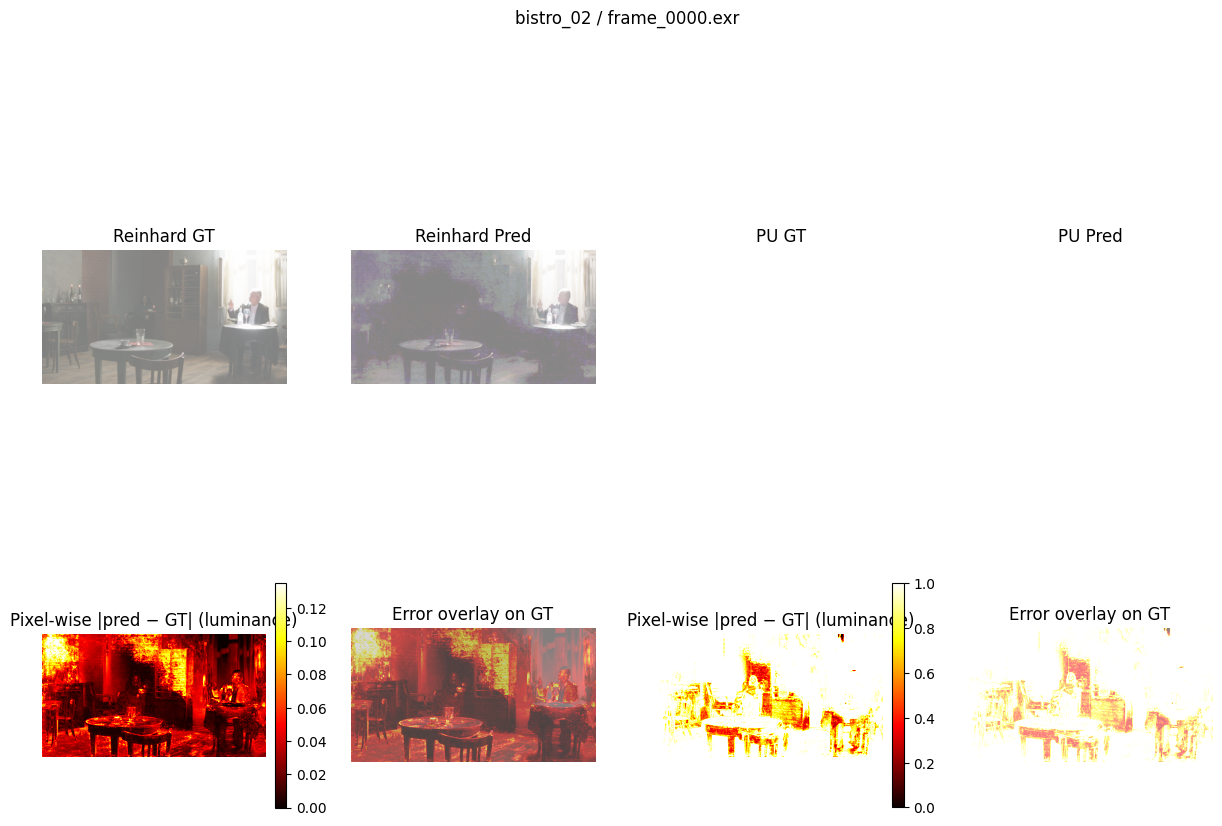

In [28]:
VIDEO_INDEX = 1
FRAME_INDEX = 0

video_path = video_paths[VIDEO_INDEX]
all_ims = sorted(os.listdir(os.path.join(pred_dir, video_path)))
im_paths = all_ims[::DS][:NUM_FILES]
im_name = im_paths[FRAME_INDEX]
pred_im_path = os.path.join(pred_dir, video_path, im_name)
gt_im_path = os.path.join(gt_dir, video_path, im_name)

cv2_hdr_pred = read_image(pred_im_path)
cv2_hdr_gt = read_image(gt_im_path)
cv2_hdr_gt = pre_hdr_p3(cv2_hdr_gt)  
cv2_hdr_pred, cv2_hdr_gt, _ = align_hdr_pred_to_gt(cv2_hdr_pred, cv2_hdr_gt)
reinhard_pred = reinhard_tonemap(cv2_hdr_pred)
reinhard_gt = reinhard_tonemap(cv2_hdr_gt)
pu_pred = pu(cv2_hdr_pred)
pu_gt = pu(cv2_hdr_gt)
print("pu_gt:", pu_gt.min(), pu_gt.max(), pu_gt.shape, np.any(np.isnan(pu_gt)))
print("pu_pred:", pu_pred.min(), pu_pred.max(), pu_pred.shape, np.any(np.isnan(pu_pred)))

err = np.abs(reinhard_pred.astype(np.float64) - reinhard_gt.astype(np.float64))
err2 = np.abs(pu_pred.astype(np.float64) - pu_gt.astype(np.float64))

w = np.array([0.2126, 0.7152, 0.0722])
err_lum = np.clip(np.tensordot(err, w, axes=(-1, 0)), 0, 1)
err2_lum = np.tensordot(err2, w, axes=(-1, 0))
err2_vmax = np.percentile(err2_lum, 99)

# PU values are ~0-600; normalize to [0,1] for imshow
pu_lo = np.percentile(np.stack([pu_gt, pu_pred]), 1)
pu_hi = np.percentile(np.stack([pu_gt, pu_pred]), 99)
pu_gt_display = np.clip((pu_gt.astype(np.float64) - pu_lo) / (pu_hi - pu_lo + 1e-8), 0, 1)
pu_pred_display = np.clip((pu_pred.astype(np.float64) - pu_lo) / (pu_hi - pu_lo + 1e-8), 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 10))
axes[0, 0].imshow(np.clip(reinhard_gt, 0, 1))
axes[0, 0].set_title("Reinhard GT")
axes[0, 0].axis("off")

axes[0, 1].imshow(np.clip(reinhard_pred, 0, 1))
axes[0, 1].set_title("Reinhard Pred")
axes[0, 1].axis("off")

im_err = axes[1, 0].imshow(err_lum, cmap="hot", vmin=0, vmax=np.percentile(err_lum, 99))
axes[1, 0].set_title("Pixel-wise |pred − GT| (luminance)")
axes[1, 0].axis("off")
plt.colorbar(im_err, ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(np.clip(reinhard_gt, 0, 1))
axes[1, 1].imshow(err_lum, cmap="hot", alpha=0.5, vmin=0, vmax=np.percentile(err_lum, 99))
axes[1, 1].set_title("Error overlay on GT")
axes[1, 1].axis("off")

# PU (normalized to [0,1] so imshow displays correctly)
axes[0, 2].imshow(pu_gt_display)
axes[0, 2].set_title("PU GT")
axes[0, 2].axis("off")

axes[0, 3].imshow(pu_pred_display)
axes[0, 3].set_title("PU Pred")
axes[0, 3].axis("off")

im_err2 = axes[1, 2].imshow(err2_lum, cmap="hot", vmin=0, vmax=err2_vmax)
axes[1, 2].set_title("Pixel-wise |pred − GT| (PU luminance)")
axes[1, 2].axis("off")
plt.colorbar(im_err2, ax=axes[1, 2], fraction=0.046, pad=0.04)

axes[1, 3].imshow(pu_gt_display)
axes[1, 3].imshow(err2_lum, cmap="hot", alpha=0.5, vmin=0, vmax=err2_vmax)
axes[1, 3].set_title("Error overlay on PU GT")
axes[1, 3].axis("off")

plt.suptitle(f"{video_path} / {im_name}")
plt.tight_layout()
plt.show()


In [ ]:
# ----------------------------
# Initialize metrics (shared state)
# ----------------------------
cvvdp_metric = initialize_cvvdp()
reinhard_fvd_metric = initialize_fvd()
reinhard_fid_metric = initialize_fid()
cvvdp_scores = []

In [ ]:
def process_one_frame(idx, pred_im_path, gt_im_path):
    """Per-frame computation; returns dict for main thread to aggregate."""
    cv2_hdr_pred = read_image(pred_im_path)
    cv2_hdr_gt = read_image(gt_im_path)
    cv2_hdr_gt = pre_hdr_p3(cv2_hdr_gt)
    cv2_hdr_pred, cv2_hdr_gt, _ = align_hdr_pred_to_gt(cv2_hdr_pred, cv2_hdr_gt)

    hdrvdp3_val = hdr_vdp3(cv2_hdr_pred, cv2_hdr_gt)
    reinhard_pred = reinhard_tonemap(cv2_hdr_pred)
    reinhard_gt   = reinhard_tonemap(cv2_hdr_gt)

    return {
        "idx": idx,
        "cv2_hdr_pred": cv2_hdr_pred,
        "cv2_hdr_gt": cv2_hdr_gt,
        "reinhard_pred": reinhard_pred,
        "reinhard_gt": reinhard_gt,
    }

In [ ]:
# ----------------------------
# Main loop over videos (run this cell to compute; re-run to re-run only this part)
# ----------------------------
for video_path in tqdm(video_paths, desc="Videos", unit="video"):
    pred_video_dir = os.path.join(pred_dir, video_path)
    gt_video_dir   = os.path.join(gt_dir, video_path)

    all_ims = sorted(os.listdir(pred_video_dir))
    im_paths = all_ims[::DS][:NUM_FILES]
    assert len(im_paths) >= 1, (
        f"Need at least 1 frame after DS={DS}, found {len(im_paths)} in {pred_video_dir}"
    )

    reinhard_preds = [None] * len(im_paths)
    reinhard_gts   = [None] * len(im_paths)
    hdr_preds      = [None] * len(im_paths)
    hdr_gts        = [None] * len(im_paths)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        it = enumerate(im_paths)
        futures = {}
        for idx, im_name in islice(it, MAX_IN_FLIGHT):
            pred_im_path = os.path.join(pred_video_dir, im_name)
            gt_im_path   = os.path.join(gt_video_dir, im_name)
            fut = ex.submit(process_one_frame, idx, pred_im_path, gt_im_path)
            futures[fut] = idx

        pbar = tqdm(total=len(im_paths), desc=f"Frames [{video_path}]", unit="frame", leave=False)
        while futures:
            for fut in as_completed(list(futures.keys())):
                _ = futures.pop(fut)
                out = fut.result()
                idx = out["idx"]
                reinhard_preds[idx] = out["reinhard_pred"]
                reinhard_gts[idx]   = out["reinhard_gt"]
                hdr_preds[idx]      = out["cv2_hdr_pred"]
                hdr_gts[idx]        = out["cv2_hdr_gt"]
                del out
                pbar.update(1)
                try:
                    idx2, im_name2 = next(it)
                    pred_im_path2 = os.path.join(pred_video_dir, im_name2)
                    gt_im_path2   = os.path.join(gt_video_dir, im_name2)
                    fut2 = ex.submit(process_one_frame, idx2, pred_im_path2, gt_im_path2)
                    futures[fut2] = idx2
                except StopIteration:
                    pass
                break
        pbar.close()

    cvvdp_score = cvvdp(hdr_preds, hdr_gts, cvvdp_metric)
    cvvdp_scores.append(cvvdp_score)
    fid_update(reinhard_preds, reinhard_gts, reinhard_fid_metric)
    fvd_update(reinhard_preds, reinhard_gts, reinhard_fvd_metric)

    del reinhard_preds, reinhard_gts, hdr_preds, hdr_gts, im_paths
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
    except Exception:
        pass

In [ ]:
# ----------------------------
# Final metrics & CSV
# ----------------------------
R_FID = float(compute_fid(reinhard_fid_metric))
R_FVD = float(compute_fvd(reinhard_fvd_metric))

Path(EVAL_OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
out_csv = Path(EVAL_OUTPUT_DIR) / f"results_{method}_{dataset}_{type_}_{NUM_FILES}_ds{DS}_reinhard.csv"
fieldnames = ["CVVDP", "R-FID", "R-FVD"]
row = {"R-FID": R_FID, "R-FVD": R_FVD}
row["CVVDP"] = float(np.mean(cvvdp_scores)) if cvvdp_scores else ""

with open(out_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerow(row)

print("R-FID:", R_FID)
print("R-FVD:", R_FVD)
print("CVVDP (mean):", row["CVVDP"])
print("Wrote:", out_csv)